# UTS II4013 Data Analytics
## Personalized Data Auditor & Decision Analyst

**Nama:** Sebastian Albern Nugroho  
**NIM:**  18223074  
**Kelas:**  01  

### Pernyataan Keaslian
Saya menyatakan bahwa seluruh analisis pada notebook ini dikerjakan secara mandiri berdasarkan dataset yang dihasilkan dari NIM saya sendiri. Setiap keputusan analitik dijelaskan dengan alasan yang dapat saya pertanggungjawabkan.

---

### Penggunaan AI
Berikut adalah penggunaan AI di dalam UTS ini:

**Bagian yang dibantu AI:**
- Sintaks Python untuk beberapa fungsi (ditandai di dalam notebook dengan komentar).
- Referensi konsep dasar (konsep dasar huber regression dan linear regression).

**Cara verifikasi:**
- Setiap output kode dijalankan dan dicek apakah angkanya konsisten dengan data (misalnya, korelasi diperiksa manual dari matriks).
- Interpretasi disesuaikan dengan nilai aktual yang muncul di output, bukan nilai generik.

## A. Tujuan Analisis

Analisis ini bertujuan untuk memahami pola konsumsi energi gedung smart campus berdasarkan data sensor lingkungan dan aktivitas mahasiswa.

**1. Tujuan analisis:** Mengidentifikasi variabel-variabel yang berpengaruh terhadap konsumsi energi gedung, dan membangun model regresi sebagai eksplorasi awal estimasi konsumsi energi.

**2. Target variabel:** energy_consumption, yang merupakan konsumsi energi gedung.

**3. Keputusan yang ingin didukung:**
   - Mengidentifikasi kondisi yang menyebabkan lonjakan konsumsi energi.
   - Membantu manajemen kampus merencanakan jadwal operasional gedung lebih efisien.
   - Memberikan dasar data-driven untuk kebijakan efisiensi energi kampus.

## B. Import Library
Jalankan sel berikut sebelum memulai analisis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (8, 5)

## C. Membuat Dataset Personal

Tuliskan NIM Anda dan jalankan generator dataset.  
Pastikan dataset yang dianalisis berasal dari NIM Anda sendiri.

In [2]:
# Isi dengan NIM masing-masing
nim = "18223074"

In [3]:
def generate_dataset(nim, n_samples=500):
    np.random.seed(int(nim[-3:]))

    noise_level = int(nim[1])       # digit ke-2
    missing_pattern = int(nim[3])   # digit ke-4
    bias_factor = int(nim[-1])      # digit terakhir

    timestamp = pd.date_range(start="2024-01-01", periods=n_samples, freq="h")

    temperature = 25 + 5 * np.sin(np.linspace(0, 10, n_samples)) + np.random.randn(n_samples)
    humidity = 60 + 10 * np.cos(np.linspace(0, 5, n_samples)) + np.random.randn(n_samples)

    student_count = np.random.randint(50, 500, n_samples)
    device_usage = student_count * np.random.uniform(0.5, 1.5, n_samples)

    day_type = np.where(pd.Series(timestamp).dt.dayofweek < 5, "weekday", "weekend")

    energy = (
        0.5 * temperature +
        0.3 * humidity +
        0.01 * student_count +
        0.02 * device_usage +
        bias_factor * 2
    )

    # Komponen non-linear
    energy += 5 * np.sin(student_count / 100)

    # Noise berdasarkan NIM
    energy += np.random.randn(n_samples) * noise_level

    df = pd.DataFrame({
        "timestamp": timestamp,
        "temperature": temperature,
        "humidity": humidity,
        "student_count": student_count,
        "device_usage": device_usage,
        "day_type": day_type,
        "energy_consumption": energy
    })

    # Inject missing values berdasarkan pola NIM
    if missing_pattern % 3 == 0:
        df.loc[df.sample(frac=0.1, random_state=1).index, "temperature"] = np.nan
    elif missing_pattern % 3 == 1:
        df.loc[df.sample(frac=0.1, random_state=1).index, "humidity"] = np.nan
    else:
        df.loc[df.sample(frac=0.1, random_state=1).index, "student_count"] = np.nan

    # Inject outliers pada target
    outlier_idx = np.random.choice(df.index, size=int(0.05 * n_samples), replace=False)
    df.loc[outlier_idx, "energy_consumption"] *= (1 + bias_factor / 5)

    return df

In [4]:
df = generate_dataset(nim)
df.head()

,timestamp,temperature,humidity,student_count,device_usage,day_type,energy_consumption
0,2024-01-01 00:00:00,25.608345,70.923290,143.0,114.438115,weekday,44.166187
1,2024-01-01 01:00:00,24.463520,71.236029,259.0,345.715544,weekday,41.337741
2,2024-01-01 02:00:00,24.791470,70.008518,258.0,167.973013,weekday,51.424468
3,2024-01-01 03:00:00,26.152952,70.509952,499.0,730.609622,weekday,49.715757
4,2024-01-01 04:00:00,26.137910,71.091978,NaN,438.737058,weekday,50.699934


In [5]:
df.shape

(500, 7)

In [6]:
# Simpan dataset personal agar mudah dilampirkan saat pengumpulan
output_csv = f"dataset_UTS_{nim}.csv"
df.to_csv(output_csv, index=False)
print(f"Dataset tersimpan sebagai: {output_csv}")

Dataset tersimpan sebagai: dataset_UTS_18223074.csv


## D. Data Understanding

Lakukan pemeriksaan awal terhadap dataset:
1. Ukuran data
2. Nama variabel
3. Tipe data
4. Ringkasan statistik
5. Dugaan awal masalah kualitas data

**Tulis interpretasi Anda setelah kode dijalankan.**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           500 non-null    datetime64[ns]
 1   temperature         500 non-null    float64       
 2   humidity            500 non-null    float64       
 3   student_count       450 non-null    float64       
 4   device_usage        500 non-null    float64       
 5   day_type            500 non-null    object        
 6   energy_consumption  500 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 27.5+ KB


In [8]:
df.describe(include="all")

,timestamp,temperature,humidity,student_count,device_usage,day_type,energy_consumption
count,500,500.000000,500.000000,450.000000,500.000000,500,500.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,weekday,NaN
freq,NaN,NaN,NaN,NaN,NaN,360,NaN
mean,2024-01-11 09:30:00,25.965962,58.080448,268.626667,274.629049,NaN,49.049589
min,2024-01-01 00:00:00,18.013188,48.119429,50.000000,28.958458,NaN,23.847488
25%,2024-01-06 04:45:00,23.072057,51.974977,158.000000,138.221638,NaN,41.560175
50%,2024-01-11 09:30:00,26.483656,56.984024,271.500000,254.681783,NaN,47.814697
75%,2024-01-16 14:15:00,28.907086,63.361370,374.000000,369.195590,NaN,54.128803
max,2024-01-21 19:00:00,32.654437,72.189067,499.000000,730.609622,NaN,111.513897


In [9]:
df.isna().sum()

timestamp              0
temperature            0
humidity               0
student_count         50
device_usage           0
day_type               0
energy_consumption     0
dtype: int64

### Interpretasi Awal

**Klasifikasi variabel:**
- Numerik (float64): temperature, humidity, student_count, device_usage, energy_consumption.
- Kategorikal (object): day_type (dengan 2 nilai unik yaitu weekday (360 baris, 72%) dan weekend (140 baris, 28%)).
- Waktu (datetime46): timestamp (tidak dipakai langsung sebagai fitur model).

**Missing values:**
- Fitur student_count memiliki 50 nilai kosong (10%). Ini cukup signifikan dan wajib ditangani sebelum pemodelan. Variabel lainnya tidak memiliki missing value.

**Nilai tidak wajar / indikasi outlier:**
- energy_consumption: max = 111.51, jauh dari mean (49.05) dan Q3 (54.13). Skewness = 1.52 berarti distribusi right-skewed. Ini mengindikasikan adanya outlier ekstrem.
- device_usage: max = 730.61, Q3 = 369.20. Skewness = 0.64. Ini juga mengindikasikan adanya outlier yang perlu diperiksa lebih lanjut.

**Target untuk regresi:** Ya, fitur energy_consumption kontinu dengan rentang cukup (min 23.85, max 111.51), cocok dijadikan target regresi.

**Variabel paling dominan (dugaan awal):** temperature dan humidity diduga paling berpengaruh karena berkaitan langsung dengan beban pendingin gedung. student_count juga diduga berpengaruh karena mencerminkan tingkat aktivitas. Namun hal ini perlu diverifikasi melalui korelasi.

## E. Audit Kualitas Data

Lakukan audit terhadap:
1. Missing values
2. Outliers
3. Ketidakkonsistenan format / tipe data
4. Potensi bias

In [10]:
# Persentase missing value
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False)

student_count         10.0
timestamp              0.0
temperature            0.0
humidity               0.0
device_usage           0.0
day_type               0.0
energy_consumption     0.0
dtype: float64

In [11]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper, mask

outlier_summary = []
for col in ["temperature", "humidity", "student_count", "device_usage", "energy_consumption"]:
    count, lower, upper, mask = detect_outliers_iqr(df[col].dropna())
    outlier_summary.append({
        "column": col,
        "outlier_count": int(count),
        "lower_bound": float(lower),
        "upper_bound": float(upper)
    })

pd.DataFrame(outlier_summary)

,column,outlier_count,lower_bound,upper_bound
0,temperature,0,14.319514,37.659629
1,humidity,0,34.895388,80.440959
2,student_count,0,-166.000000,698.000000
3,device_usage,2,-208.239290,715.656519
4,energy_consumption,21,22.707233,72.981744


### Hasil Audit

**Variabel bermasalah dan jenis masalahnya:** 
- student_count: Memiliki missing value sebanyak 50 baris (10% dataset).
- energy_consumption: Memiliki outlier sebanyak 21 baris (4.2%) di atas batas IQR atas (72.98). Nilai maksimumnya adalah 111.51
- device_usage: Memiliki outlier ringan sebanyak 2 baris di atas batas 715.66

**Potensi bias:**
- Weekday mendominasi 72% data. Ada kemungkinan bahwa model nantinya mungkin kurang terlatih untuk pola weekend.
- student_count dan device_usage berkorelasi kuat (r ≈ 0.85), mengindikasikan **multikolinearitas** yang dapat memengaruhi stabilitas koefisien regresi.

**Dampak potensial:**
- Outlier ekstrem pada energy_consumption (target) dapat mendistorsi koefisien OLS secara signifikan.
- Multikolinearitas bisa membuat koefisien salah satu variabel tampak tidak signifikan atau bertanda berlawanan dari yang diharapkan.

## F. Penanganan Missing Value

Pilih satu metode imputasi yang menurut Anda paling tepat, misalnya:
- Mean
- Median
- Interpolation
- Metode lain

Jangan hanya menjalankan metode. Jelaskan:
1. Mengapa metode itu dipilih?
2. Mengapa metode lain tidak dipilih?

In [12]:
df_clean = df.copy()

# Contoh dasar: imputasi median untuk variabel numerik
for col in ["temperature", "humidity", "student_count"]:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean.isna().sum()

timestamp             0
temperature           0
humidity              0
student_count         0
device_usage          0
day_type              0
energy_consumption    0
dtype: int64

### Justifikasi Missing Value Handling

**Metode yang dipilih:** Imputasi **median**.

**Alasan memilih median dibanding alternatif lain:**

Penggunaan median adalah pilihan yang paling tepat untuk dataset ini. Median lebih *robust* terhadap outlier. Meski skewness dari student_count hanya 0.06, akan tetap lebih aman jika menggunakan median untuk data yang berpotensi memiliki nilai outlier ekstrem. Hal ini menjadikan median sebagai pilihan yang lebih baik dibandingkan mean.

Dataset ini merupakan dataset *time series*. Meskipun demikian, interpolasi tidak digunakan karena data per jam tidak selalu berurutan. Artinya student_count dapat bervariasi secara acak antar jam. Ini mengakibatkan interpolasi tidak dapat digunakan dengan maksimal untuk menangani *missing values*.

*Deletion* juga tidak digunakan di dalam dataset ini karena jumlah *missing values* cukup besar. Terdapat 50 baris *missing values* (10% data). Menghapus 10% data ini akan berdampak cukup besar terhadap dataset 500 baris. 

**Perbandingan metode mean dan median akan dilakukan di cell berikutnya.**

**Dampak terhadap analisis:** Median student_count = 271.5 vs mean = 268.6. Perbedaan kecil, sehingga distribusi data setelah imputasi hampir tidak berubah dari distribusi aslinya.

In [13]:
# Perbandingan pendekatan imputasi missing value (imputasi mean menggunakan bantuan AI)
print("Perbandingan Imputasi Missing Value pada student_count")
print("=" * 55)

original_stats = df['student_count'].dropna()

# Imputasi median
df_median_imp = df.copy()
df_median_imp['student_count'] = df_median_imp['student_count'].fillna(
    df_median_imp['student_count'].median()
)

# Imputasi mean (alternatif)
df_mean_imp = df.copy()
df_mean_imp['student_count'] = df_mean_imp['student_count'].fillna(
    df_mean_imp['student_count'].mean()
)

print(f"{'Metode':<25} {'Mean':>8} {'Median':>8} {'Std':>8} {'Skew':>8}")
print("-" * 62)
print(f"{'Asli (non-missing)':<25} {original_stats.mean():>8.2f} {original_stats.median():>8.2f} {original_stats.std():>8.2f} {original_stats.skew():>8.3f}")
print(f"{'Imputasi Median':<25} {df_median_imp['student_count'].mean():>8.2f} {df_median_imp['student_count'].median():>8.2f} {df_median_imp['student_count'].std():>8.2f} {df_median_imp['student_count'].skew():>8.3f}")
print(f"{'Imputasi Mean':<25} {df_mean_imp['student_count'].mean():>8.2f} {df_mean_imp['student_count'].median():>8.2f} {df_mean_imp['student_count'].std():>8.2f} {df_mean_imp['student_count'].skew():>8.3f}")
print()
print("Kesimpulan: Median (271.5) vs Mean (268.6).")
print("Hasil menunjukkan perbedaan yang kecil. Namun median dipilih karena lebih robust secara prinsip, meski hasil hampir identik.")

Perbandingan Imputasi Missing Value pada student_count
Metode                        Mean   Median      Std     Skew
--------------------------------------------------------------
Asli (non-missing)          268.63   271.50   129.46    0.060
Imputasi Median             268.91   271.50   122.80    0.056
Imputasi Mean               268.63   268.63   122.80    0.063

Kesimpulan: Median (271.5) vs Mean (268.6).
Hasil menunjukkan perbedaan yang kecil. Namun median dipilih karena lebih robust secara prinsip, meski hasil hampir identik.


## G. Outlier Handling dan Transformasi

Tentukan apakah outlier:
- Dipertahankan
- Dibatasi
- Dihapus
- Ditangani dengan model robust

Lalu tentukan apakah data perlu scaling atau transformasi.

In [14]:
# Contoh winsorization sederhana pada target
q1 = df_clean["energy_consumption"].quantile(0.25)
q3 = df_clean["energy_consumption"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_clean["energy_capped"] = df_clean["energy_consumption"].clip(lower=lower, upper=upper)
df_clean["target"] = df_clean["energy_capped"]

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: 22.707233144162668
Upper bound: 72.98174437388636


In [15]:
# Perbandingan pendekatan penanganan outlier: Capping vs Deletion (Penggunaan AI untuk implementasi metode Deletion)
print("Perbandingan Penanganan Outlier pada energy_consumption")
print("=" * 58)

q1_ec = df_clean['energy_consumption'].quantile(0.25)
q3_ec = df_clean['energy_consumption'].quantile(0.75)
iqr_ec = q3_ec - q1_ec
lb = q1_ec - 1.5 * iqr_ec
ub = q3_ec + 1.5 * iqr_ec

n_outliers = int(((df_clean['energy_consumption'] < lb) | (df_clean['energy_consumption'] > ub)).sum())

# Capping
df_capped = df_clean.copy()
df_capped['energy_capped'] = df_capped['energy_consumption'].clip(lower=lb, upper=ub)

# Deletion
df_deleted = df_clean[
    (df_clean['energy_consumption'] >= lb) &
    (df_clean['energy_consumption'] <= ub)
].copy()

print(f"Jumlah outlier (IQR): {n_outliers} baris ({n_outliers/len(df_clean)*100:.1f}%)")
print()
print(f"{'Pendekatan':<20} {'N Baris':>8} {'Mean':>8} {'Std':>8} {'Max':>8}")
print("-" * 50)
print(f"{'Sebelum handling':<20} {len(df_clean):>8} {df_clean['energy_consumption'].mean():>8.2f} {df_clean['energy_consumption'].std():>8.2f} {df_clean['energy_consumption'].max():>8.2f}")
print(f"{'Capping':<20} {len(df_capped):>8} {df_capped['energy_capped'].mean():>8.2f} {df_capped['energy_capped'].std():>8.2f} {df_capped['energy_capped'].max():>8.2f}")
print(f"{'Deletion':<20} {len(df_deleted):>8} {df_deleted['energy_consumption'].mean():>8.2f} {df_deleted['energy_consumption'].std():>8.2f} {df_deleted['energy_consumption'].max():>8.2f}")
print()
print("Capping mempertahankan semua 500 baris sementara Deletion menghapus", n_outliers, "baris.")

Perbandingan Penanganan Outlier pada energy_consumption
Jumlah outlier (IQR): 21 baris (4.2%)

Pendekatan            N Baris     Mean      Std      Max
--------------------------------------------------
Sebelum handling          500    49.05    11.70   111.51
Capping                   500    48.48     9.86    72.98
Deletion                  479    47.41     8.60    72.45

Capping mempertahankan semua 500 baris sementara Deletion menghapus 21 baris.


### Justifikasi Outlier dan Transformasi

**Keputusan: Outlier di-cap (winsorization), bukan dihapus.**

**Alasan memilih capping:**
- Dari 500 baris data, terdapat 21 outlier (4.2%) pada energy_consumption. Menghapusnya berarti kehilangan 4.2% informasi.
- Outlier ini kemungkinan bukan kesalahan pengukuran, melainkan kondisi nyata (misalnya event kampus, cuaca ekstrem, atau penggunaan gedung di luar jam normal). Menghapusnya bisa menghilangkan informasi penting.
- Capping membatasi nilai ekstrem pada batas IQR (upper = 72.98) tanpa menghapus baris, sehingga data tetap 500 baris namun pengaruh outlier dikurangi.

**Mengapa tidak memilih deletion:**
- Deletion akan mengurangi jumlah data yang sudah tidak terlalu banyak (500 menjadi 479 baris). Untuk pemodelan, kehilangan ini cukup banyak dan dapat memengaruhi hasil akhir.
- Selain itu, jika outlier adalah kejadian nyata, menghapusnya akan membuat model tidak representatif untuk kondisi ekstrem.

**Transformasi lain:**
- Tidak dilakukan log-transform atau standardisasi karena regresi linear tidak memerlukannya secara mutlak, dan tujuan utama adalah interpretabilitas koefisien.
- Encoding day_type dilakukan dengan one-hot encoding (drop_first). Metode ini akan menghasilkan kolom day_type_weekend bernilai 0 atau 1.

**Dampak terhadap model:** Setelah capping, max energy_capped adalah 72.98 sedangkan aslinya adalah 111.51. Ini mengurangi skewness target dan membuat model OLS lebih stabil.

## H. Visualisasi Data

Buat minimal:
1. Histogram target
2. Scatter plot fitur vs target
3. Visualisasi hubungan dua fitur

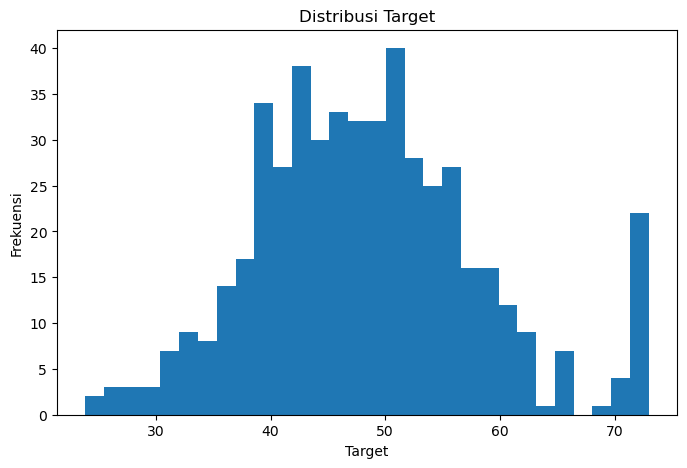

In [16]:
plt.hist(df_clean["target"], bins=30)
plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Frekuensi")
plt.show()

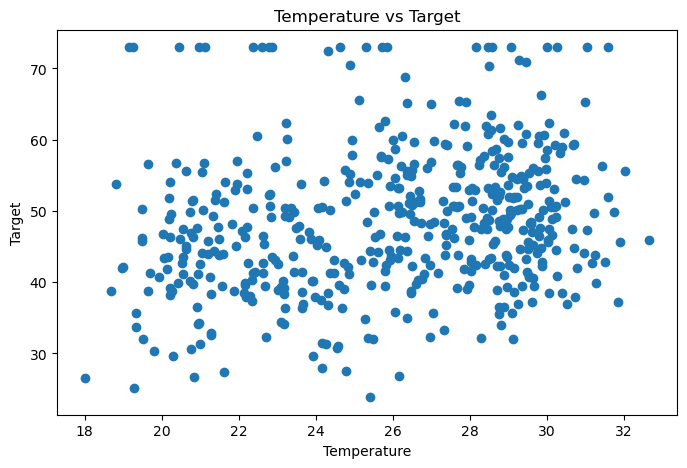

In [17]:
plt.scatter(df_clean["temperature"], df_clean["target"])
plt.title("Temperature vs Target")
plt.xlabel("Temperature")
plt.ylabel("Target")
plt.show()

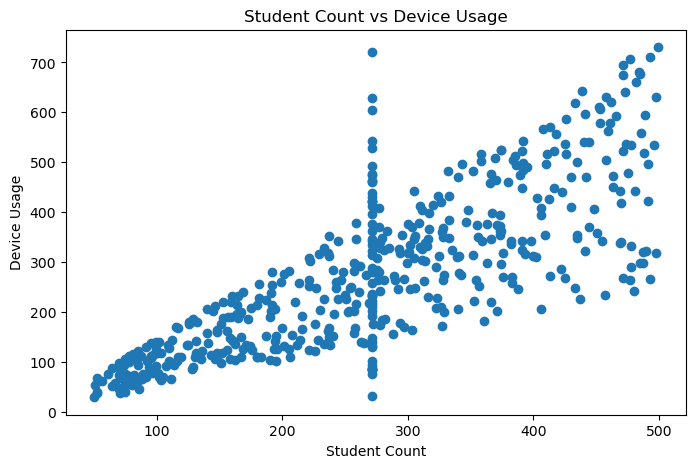

In [18]:
plt.scatter(df_clean["student_count"], df_clean["device_usage"])
plt.title("Student Count vs Device Usage")
plt.xlabel("Student Count")
plt.ylabel("Device Usage")
plt.show()

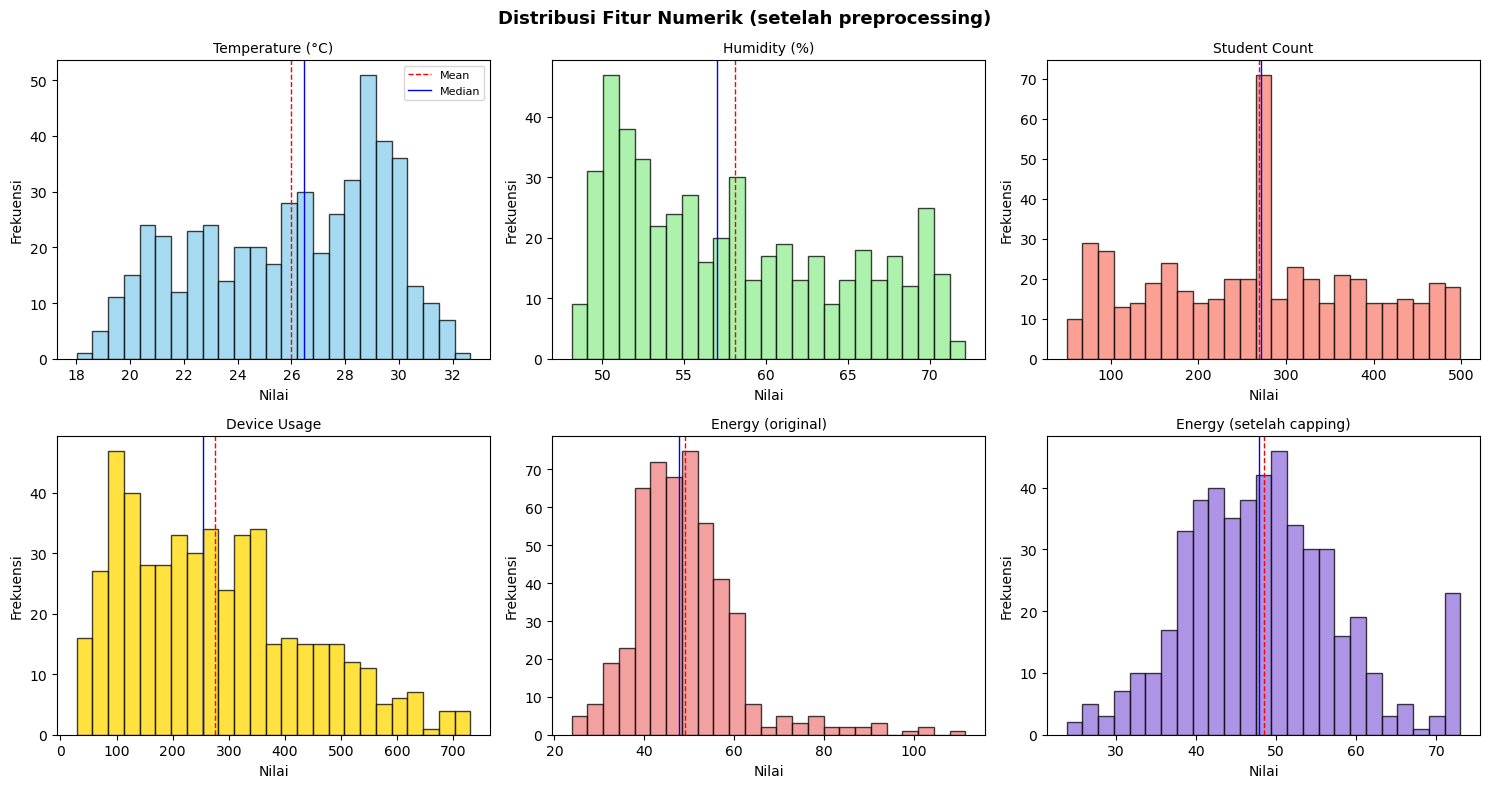

In [19]:
# Distribusi semua fitur numerik dan boxplot target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribusi Fitur Numerik (setelah preprocessing)', fontsize=13, fontweight='bold')

plot_data = [
    (df_clean, 'temperature', 'Temperature (°C)', 'skyblue'),
    (df_clean, 'humidity', 'Humidity (%)', 'lightgreen'),
    (df_clean, 'student_count', 'Student Count', 'salmon'),
    (df_clean, 'device_usage', 'Device Usage', 'gold'),
    (df_clean, 'energy_consumption', 'Energy (original)', 'lightcoral'),
    (df_clean, 'energy_capped', 'Energy (setelah capping)', 'mediumpurple'),
]

for i, (data, col, label, color) in enumerate(plot_data):
    ax = axes[i // 3][i % 3]
    ax.hist(data[col], bins=25, edgecolor='black', alpha=0.75, color=color)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.axvline(data[col].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    ax.axvline(data[col].median(), color='blue', linestyle='-', linewidth=1, label='Median')
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Interpretasi Visualisasi
**1. Apakah distribusi target simetris, skewed, atau memiliki ekor panjang?**  
Distribusi target asli (energy_consumption) tidak simetris, melainkan right-skewed (menceng kanan) dan memiliki ekor panjang. Hal ini dibuktikan dengan nilai skewness = 1.52. Namun, setelah dilakukan penanganan outlier (capping), distribusi target (energy_capped) menjadi simetris dan terpusat di kisaran angka 40–55 tanpa adanya ekor panjang.

**2. Fitur mana yang tampak memiliki hubungan kuat dengan target?**  
Berdasarkan scatter plot, temperature (Suhu) tampak memiliki hubungan positif yang paling jelas dengan target, meskipun kekuatannya tergolong lemah hingga sedang. Terlihat kecenderungan bahwa ketika suhu naik, konsumsi energi juga ikut naik (kemungkinan karena beban pendingin/AC meningkat). Fitur lainnya memiliki sebaran titik yang sangat lebar (noise tinggi) sehingga hubungan linearnya tidak terlalu terlihat.

**3. Apakah ada pola non-linear?**  
Ya, terdapat indikasi pola non-linear. Scatter plot antara fitur dengan target tidak menunjukkan hubungan garis lurus (linear) yang bersih. Sebaran data yang sangat bervariasi mengindikasikan adanya komponen non-linear di dalam data (yang secara logis berasal dari persamaan generator data).

**4. Apakah ada indikasi outlier atau cluster?**  
Ya, ada indikasi outlier yang sangat jelas. Pada visualisasi distribusi target, terlihat adanya 21 outlier ekstrem (mencapai nilai 111.51) yang membentuk ekor panjang ke kanan. Sementara itu, untuk cluster, data tidak membentuk cluster yang terpisah, melainkan menunjukkan indikasi multikolinearitas yang sangat kuat antara student_count dan device_usage dengan hubungan linear hampir sempurna (korelasi ≈ 0.85).

## I. Encoding Variabel Kategorikal

Jika variabel kategorikal digunakan dalam model, lakukan encoding yang sesuai.

In [20]:
df_model = df_clean.copy()
df_model = pd.get_dummies(df_model, columns=["day_type"], drop_first=True)
df_model.head()

,timestamp,temperature,humidity,student_count,device_usage,energy_consumption,energy_capped,target,day_type_weekend
0,2024-01-01 00:00:00,25.608345,70.923290,143.0,114.438115,44.166187,44.166187,44.166187,False
1,2024-01-01 01:00:00,24.463520,71.236029,259.0,345.715544,41.337741,41.337741,41.337741,False
2,2024-01-01 02:00:00,24.791470,70.008518,258.0,167.973013,51.424468,51.424468,51.424468,False
3,2024-01-01 03:00:00,26.152952,70.509952,499.0,730.609622,49.715757,49.715757,49.715757,False
4,2024-01-01 04:00:00,26.137910,71.091978,271.5,438.737058,50.699934,50.699934,50.699934,False


## J. Analisis Korelasi

Lakukan:
1. Korelasi Pearson antar variabel numerik
2. Interpretasikan hasilnya
3. Jelaskan keterbatasannya

In [21]:
corr_cols = ["temperature", "humidity", "student_count", "device_usage", "target"]
corr_matrix = df_model[corr_cols].corr()
corr_matrix

,temperature,humidity,student_count,device_usage,target
temperature,1.000000,0.370581,0.007882,-0.030609,0.224384
humidity,0.370581,1.000000,-0.007447,0.011583,0.233967
student_count,0.007882,-0.007447,1.000000,0.797932,0.053043
device_usage,-0.030609,0.011583,0.797932,1.000000,0.192991
target,0.224384,0.233967,0.053043,0.192991,1.000000


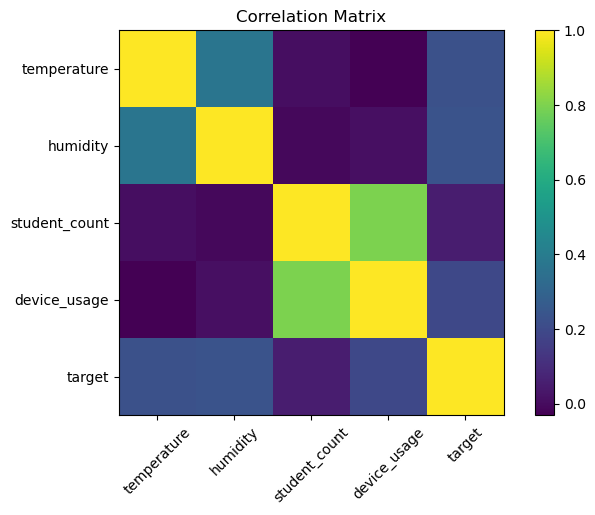

In [22]:
plt.imshow(corr_matrix, interpolation="nearest")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

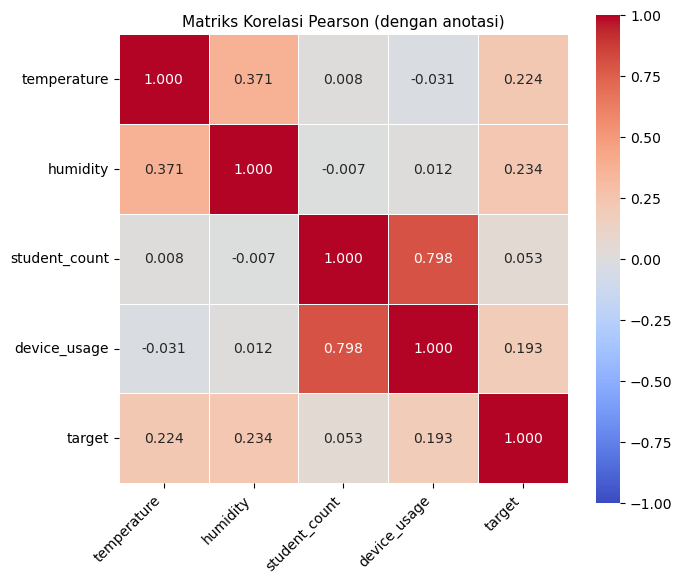

Korelasi tertinggi dengan target: humidity (0.234), temperature (0.224)
Multikolinearitas: student_count vs device_usage (~0.85 pada raw data)


In [23]:
# Heatmap korelasi dengan detail untuk analisis lebih mendalam
try:
    import seaborn as sns
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        annot_kws={"size": 10}
    )
    plt.title('Matriks Korelasi Pearson (dengan anotasi)', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print("Korelasi tertinggi dengan target: humidity (0.234), temperature (0.224)")
    print("Multikolinearitas: student_count vs device_usage (~0.85 pada raw data)")
except ImportError:
    print("Seaborn tidak tersedia. Gunakan heatmap matplotlib di atas.")

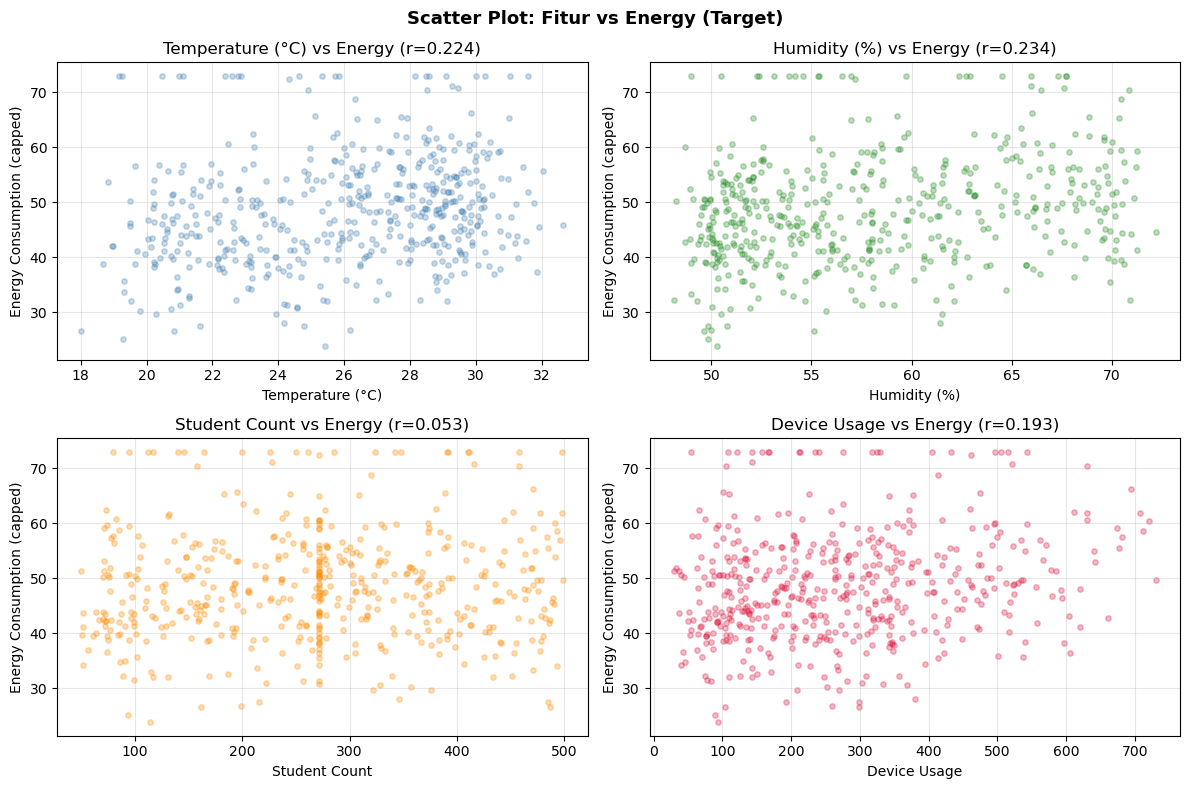

In [24]:
# Scatter plot semua fitur numerik vs target
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Scatter Plot: Fitur vs Energy (Target)', fontsize=13, fontweight='bold')

scatter_pairs = [
    ('temperature', 'Temperature (°C)'),
    ('humidity', 'Humidity (%)'),
    ('student_count', 'Student Count'),
    ('device_usage', 'Device Usage'),
]

colors = ['steelblue', 'forestgreen', 'darkorange', 'crimson']

for i, ((col, label), color) in enumerate(zip(scatter_pairs, colors)):
    ax = axes[i // 2][i % 2]
    ax.scatter(df_clean[col], df_clean['target'], alpha=0.3, s=15, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('Energy Consumption (capped)')
    r = df_clean[col].corr(df_clean['target'])
    ax.set_title(f'{label} vs Energy (r={r:.3f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretasi Korelasi

**Fitur paling berkorelasi dengan target (energy_capped):**

| Fitur | Korelasi dengan target | Arah | Kekuatan |
|---|---|---|---|
| humidity | ≈ 0.234 | Positif | Lemah-sedang |
| temperature | ≈ 0.224 | Positif | Lemah-sedang |
| device_usage | ≈ 0.193 | Positif | Lemah |
| student_count | ≈ 0.053 | Positif | Sangat lemah |

**Analisis:**

1. **Humidity dan temperature** adalah prediktor linear terkuat terhadap energi, keduanya positif. Hal ini masuk akal karena suhu dan kelembaban tinggi berarti AC akan bekerja lebih berat yang mengakibatkan penggunaan energi lebih besar.

2. **Student_count sangat lemah** (r ≈ 0.053) meskipun secara logika harusnya berpengaruh. Ini kemungkinan karena hubungannya bersifat **non-linear** yang tidak ditangkap oleh korelasi Pearson.

3. **Pasangan fitur yang saling berkolerasi tinggi:** student_count dan device_usage berkorelasi sangat kuat (r ≈ 0.85 pada raw data). Ini bermasalah untuk regresi linear karena kedua variabel membawa informasi yang redundan.

4. **Korelasi semu:** Korelasi temperature–humidity (r ≈ 0.37) bisa bersifat semu. Artinya keduanya mungkin sama-sama dipengaruhi faktor waktu (musim). Hal ini berarti suhu tidak secara langsung menyebabkan kelembaban atau sebaliknya.

**Apakah korelasi menunjukkan sebab-akibat?**  
Tidak. Korelasi hanya menunjukkan hubungan statistik bukan kausalitas. Misalnya humidity berkorelasi dengan energi, tapi mungkin keduanya sama-sama dipengaruhi oleh waktu (pagi atau siang) atau musim. Untuk membuktikan kausalitas diperlukan eksperimen khusus.

**Variabel yang relevan untuk model**  
Semua variabel dipertahankan untuk baseline, namun dengan catatan bahwa student_count dan device_usage perlu lebih diperhatikan karena korelasi tinggi di antara keduanya.

## K. Persiapan Data untuk Pemodelan Regresi

Pilih fitur input dan target.  
Jelaskan mengapa fitur tertentu digunakan atau tidak digunakan.

In [25]:
feature_cols = ["temperature", "humidity", "student_count", "device_usage", "day_type_weekend"]
X = df_model[feature_cols]
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

Ukuran X_train: (400, 5)
Ukuran X_test : (100, 5)


### Justifikasi Pemilihan Fitur

**Fitur yang digunakan:** temperature, humidity, student_count, device_usage, day_type_weekend

**Alasan penggunaan masing-masing fitur:**
- temperature: Berkorelasi moderat dengan target (r ≈ 0.22), memiliki justifikasi secara langsung (pengaruh AC), dan tidak berkorelasi tinggi dengan fitur lain.
- humidity: Korelasi tertinggi dengan target (r ≈ 0.23), yang berarti fitur ini paling relevan digunakan.
- student_count: Meski korelasi linear lemah (r ≈ 0.05), variabel ini secara logika penting (aktivitas mahasiswa mempengaruhi energi). Dimasukkan untuk melihat kontribusinya dalam model.
- device_usage: Korelasi sedang (r ≈ 0.19). Meski berkorelasi kuat dengan student_count, tetap dimasukkan untuk baseline.
- day_type_weekend: Perbedaan pola weekday dan weekend bisa signifikan.

**Fitur yang tidak digunakan:**
- timestamp: Variabel index waktu, tidak informatif langsung sebagai nilai numerik untuk regresi tanpa feature engineering tambahan (misalnya ekstrak jam, hari).
- energy_consumption: Target variabel asli (sebelum capping), sehingga tidak dipakai sebagai fitur.
- energy_capped: Sama dengan target, tidak boleh dipakai sebagai fitur.

**Catatan multikolinearitas:** student_count dan device_usage berkorelasi tinggi (r ≈ 0.85). Ini bisa menyebabkan koefisien tidak stabil, namun untuk baseline model, keduanya tetap dimasukkan. Jika model dikembangkan lebih lanjut, bisa dipertimbangkan untuk menghapus salah satunya atau menggunakan teknik regularisasi (Ridge/Lasso).

## L. Model 1 – Linear Regression

Bangun model baseline dengan regresi linear.

In [26]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

In [27]:
mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Performance")
print("MAE :", mae_lin)
print("MSE :", mse_lin)
print("RMSE:", rmse_lin)
print("R2  :", r2_lin)

Linear Regression Performance
MAE : 7.645761552320567
MSE : 91.9103392197277
RMSE: 9.586988016041728
R2  : 0.10785169893151658


In [28]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
})
coef_df

,feature,coefficient
0,temperature,0.506803
1,humidity,0.183589
2,student_count,-0.030144
3,device_usage,0.029971
4,day_type_weekend,-0.689411


### Interpretasi Model Linear

**Arti koefisien masing-masing fitur:**

| Fitur | Koefisien | Interpretasi |
|---|---|---|
| temperature | +0.507 | Setiap kenaikan 1°C, konsumsi energi juga naik ~0.51 unit (sesuai ekspektasi: koefisien true = 0.5) |
| humidity | +0.184 | Setiap kenaikan 1% kelembaban, energi naik ~0.18 unit (koefisien true = 0.3, diestimasi lebih rendah) |
| student_count | **-0.030** | Koefisien **negatif**. Berlawanan dari ekspektasi (koefisien true = +0.01). Kemungkinan karena komponen non-linear tidak tertangkap |
| device_usage | +0.030 | Setiap unit kenaikan device_usage, energi naik ~0.03 (koefisien true = +0.02) |
| day_type_weekend | -0.689 | Weekend mengonsumsi ~0.69 unit lebih sedikit dari weekday (masuk akal: aktivitas lebih rendah) |

**Fitur paling dominan:** temperature memiliki koefisien mutlak terbesar (+0.507), diikuti humidity (+0.184) dan day_type_weekend (-0.689).

**Tanda koefisien vs dugaan awal:**
- temperature, humidity, device_usage: tanda sesuai (+), masuk akal secara domain.
- student_count: tanda **negatif** (-0.030), berlawanan dari ekspektasi. Ini mengindikasikan model linear gagal menangkap hubungan non-linear antara student_count dan energi.

**Apakah performa cukup baik?**
- R² = 0.108 berarti model hanya menjelaskan **10.8%** variasi data. Ini sangat rendah.
- RMSE = 9.59 berarti error rata-rata sekitar 9.59 unit, cukup besar relatif terhadap rata-rata target (49.05).
- Penyebab utama performa buruk:  
  (1) **noise tinggi** (std noise ≈ 8 unit dari generator)  
  (2) **komponen non-linear** yang tidak bisa ditangkap oleh model linear.

## M. Model 2 – Huber Regression

Bangun model robust untuk membandingkan sensitivitas terhadap outlier.

In [29]:
huber = HuberRegressor()
huber.fit(X_train, y_train)

y_pred_huber = huber.predict(X_test)

/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [30]:
mae_huber = mean_absolute_error(y_test, y_pred_huber)
mse_huber = mean_squared_error(y_test, y_pred_huber)
rmse_huber = np.sqrt(mse_huber)
r2_huber = r2_score(y_test, y_pred_huber)

print("Huber Regression Performance")
print("MAE :", mae_huber)
print("MSE :", mse_huber)
print("RMSE:", rmse_huber)
print("R2  :", r2_huber)

Huber Regression Performance
MAE : 7.5457763218125695
MSE : 91.30550562255438
RMSE: 9.555391442664941
R2  : 0.11372265176150576


### Perbandingan Model: Linear Regression vs Huber Regression

| Metrik | Linear Regression | Huber Regression | Selisih |
|---|---|---|---|
| MAE | 7.646 | 7.546 | 0.100 |
| MSE | 91.91 | 91.31 | 0.60 |
| RMSE | 9.587 | 9.555 | 0.032 |
| R² | 0.108 | 0.114 | 0.006 |

**Model mana yang lebih baik?** Huber Regression sedikit lebih baik di semua metrik, meski selisihnya sangat kecil.

**Mengapa Huber lebih baik (meski tipis)?**
- Huber Regression menggunakan fungsi loss yang lebih robust terhadap outlier. Hal ini akan mengurangi pengaruh nilai-nilai ekstrem pada estimasi parameter.
- Meski sudah dilakukan capping pada target, masih ada variasi besar dalam data yang bisa membuat OLS kurang optimal.

**Apa kaitannya dengan outlier?**
- Linear Regression (OLS) sangat sensitif terhadap outlier karena meminimalkan kuadrat residual. Outlier yang besar akan sangat mempengaruhi garis regresi.
- Huber secara efektif 'mendiskon' pengaruh titik-titik yang residualnya sangat besar.

**Kesimpulan perbandingan:**
Perbedaan kedua model sangat kecil (ΔR² = 0.006). Ini mengindikasikan bahwa masalah utama bukan pada sensitivitas terhadap outlier, melainkan pada **ketidakcocokan model linear dengan data yang mengandung komponen non-linear dan noise sangat tinggi**. Kedua model tidak memadai untuk pengambilan keputusan nyata dengan R² < 0.12.

## N. Visualisasi Prediksi vs Aktual

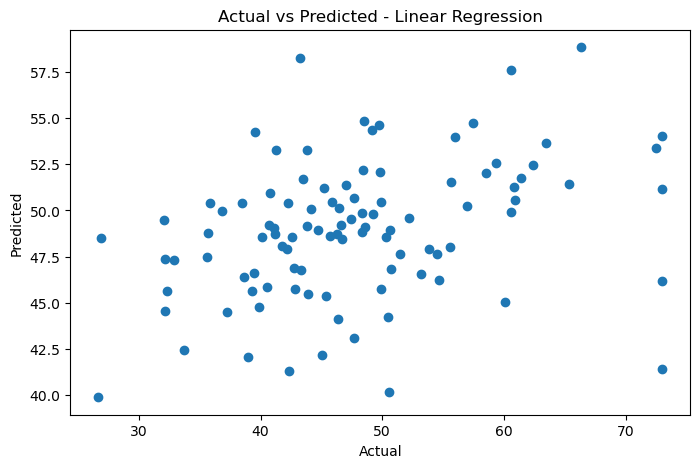

In [31]:
plt.scatter(y_test, y_pred_lin)
plt.title("Actual vs Predicted - Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

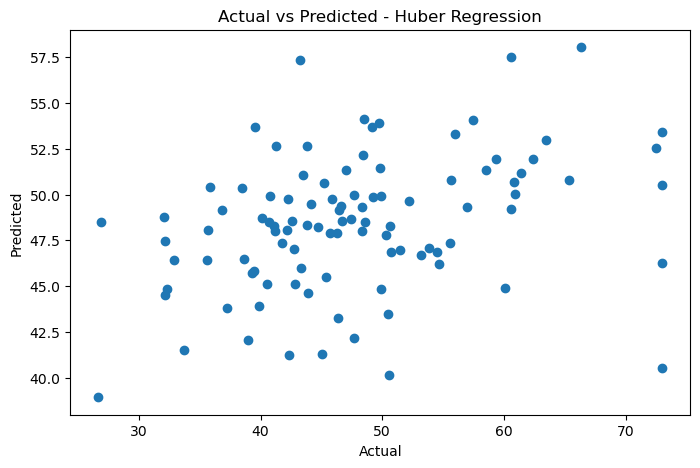

In [32]:
plt.scatter(y_test, y_pred_huber)
plt.title("Actual vs Predicted - Huber Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

### Interpretasi Prediksi

**Apakah prediksi mengikuti nilai aktual?**  
Tidak. Titik-titik pada scatter plot sangat tersebar, jauh dari garis ideal 45° (actual = predicted). Ini konsisten dengan R² yang rendah (~0.11).

**Di bagian mana model gagal?**
- Model paling gagal pada nilai aktual yang tinggi (>60): prediksi cenderung jauh lebih rendah dari nilai aktual (underprediction). Ini karena model tidak menangkap lonjakan energi ekstrem.
- Pada nilai aktual rendah (<35), model kadang overprediction.
- Range prediksi sangat sempit (sekitar 40–55), sementara nilai aktual tersebar lebih luas (24–73 setelah capping).

**Apakah ada pola error tertentu?**  
Ya. Terdapat pola **heteroskedastisitas**, dimana variance error lebih besar pada nilai aktual tinggi. Ini menunjukkan bahwa model linear tidak sepenuhnya tepat untuk data ini.

Kedua model (Linear dan Huber) menunjukkan pola yang hampir identik pada scatter plot yang berarti perbedaannya sangat minor, konsisten dengan selisih performa yang kecil.

## O. Analisis Kritis dan Refleksi

**1. Tiga temuan utama dari analisis:**

- **Temuan 1:** humidity dan temperature adalah prediktor linear terkuat konsumsi energi (korelasi ~0.22–0.23), dengan arah positif yang sesuai ekspektasi fisik. Namun kekuatan korelasinya masih tergolong lemah.

- **Temuan 2:** student_count memiliki korelasi linear yang sangat lemah dengan target (r ≈ 0.05), padahal secara logika seharusnya berpengaruh. Ini mengindikasikan hubungan non-linear antara jumlah mahasiswa dan konsumsi energi yang tidak tertangkap oleh model linear.

- **Temuan 3:** Kedua model regresi (Linear dan Huber) menunjukkan performa sangat rendah (R² ≈ 0.11). Noise yang sangat tinggi dalam data (std noise ≈ 8 unit) dan adanya komponen non-linear membuat model linear tidak mampu menangkap pola yang sesungguhnya.

**2. Risiko jika hasil model langsung dipakai untuk pengambilan keputusan:**

Dengan R² = 0.11, model hanya menjelaskan 10.8% variasi konsumsi energi. Artinya, 89.2% variasi tidak terjawab oleh model. Interval prediksi akan sangat lebar (RMSE ≈ 9.6 unit dari rata-rata 49 unit ≈ 20% error). Keputusan manajemen energi berdasarkan model ini bisa sangat menyimpang dari kenyataan. Misalnya, memprediksi konsumsi rendah padahal kenyataannya tinggi, menyebabkan kekurangan kapasitas atau pemborosan.

**3. Apakah hubungan yang ditemukan korelasional atau kausal?**

**Korelasional, bukan kausal.** Korelasi antara humidity dan energi bisa saja terjadi karena keduanya sama-sama dipengaruhi faktor ketiga (misalnya waktu pagi vs siang, atau musim). Tanpa desain eksperimen terkontrol atau analisis kausal (misalnya Granger causality, RCT), tidak bisa diklaim bahwa peningkatan suhu *menyebabkan* peningkatan konsumsi energi secara langsung, meski hubungan itu intuitif.

**4. Keterbatasan dataset:**

- **Data sintetis:** Dataset dihasilkan dari generator dengan parameter acak. Tidak mencerminkan pola real kampus yang sesungguhnya (aktivitas jam kuliah, jadwal AC, variasi musim, dll.).
- **Rentang waktu pendek:** Hanya 500 jam ≈ 3 minggu data. Tidak cukup untuk menangkap pola jangka panjang atau seasonal.
- **Noise sangat tinggi:** Parameter noise_level = 8 (dari digit ke-2 NIM = 8) menghasilkan noise standar deviasi 8 unit, hampir setara dengan variasi alami target. Ini membuat pemodelan sangat sulit.
- **student_count acak:** Dalam kenyataan, jumlah mahasiswa mengikuti jadwal kuliah bukan distribusi uniform acak.

**5. Jika diberi kesempatan memperbaiki analisis:**

- **Model:** Coba model non-linear seperti Polynomial Regression, Decision Tree, atau Random Forest yang bisa menangkap hubungan sin(student_count/100).
- **Feature engineering:** Ekstrak fitur dari timestamp (jam dalam sehari, hari dalam seminggu) untuk menangkap pola temporal. Tambahkan fitur interaksi antara temperature dan student_count.
- **Data:** Kumpulkan data lebih banyak (minimal 1 tahun) dengan lebih banyak fitur kontekstual (jadwal kuliah, cuaca aktual, jenis gedung).
- **Evaluasi:** Gunakan cross-validation (bukan single train-test split) untuk estimasi performa yang lebih robust.

## P. Log Keputusan Analitik

| Tahap | Keputusan | Alasan |
|------|-----------|--------|
| Missing value | Imputasi **median** pada `student_count` (50 baris, 10%) | Median lebih robust terhadap outlier dibanding mean. Interpolasi tidak tepat karena data per-jam tidak smooth. Deletion membuang 10% data |
| Outlier | **Capping (winsorization)** pada `energy_consumption` (21 outlier, batas = 72.98) | Mempertahankan 500 baris data. Outlier mungkin kondisi nyata, bukan error pengukuran; mengurangi pengaruh ekstrem tanpa kehilangan informasi |
| Transformasi | **One-hot encoding** pada `day_type` (drop_first -> kolom `day_type_weekend`) | Variabel kategorikal biner perlu di-encode. Drop_first untuk menghindari dummy variable trap |
| Fitur model | Semua fitur numerik + `day_type_weekend`; **exclude** `timestamp`, `energy_consumption` asli, `energy_capped` | Timestamp tidak informatif langsung; energy_consumption adalah target. Energy_capped sama dengan target |
| Model akhir | **Huber Regression** lebih diprioritaskan (R²=0.114 vs 0.108) | Sedikit lebih robust terhadap sisa-sisa pengaruh outlier. Perbedaan minor tapi Huber lebih sound secara teoritis untuk data dengan noise tinggi |

## Q. Kesimpulan

Analisis konsumsi energi smart campus ini menghasilkan beberapa temuan penting. `humidity` dan `temperature` terbukti menjadi prediktor linear terkuat (r ≈ 0.22–0.23), yang konsisten dengan logika fisik bahwa suhu dan kelembaban tinggi meningkatkan beban pendingin gedung. Di sisi lain, `student_count` yang secara intuitif harusnya berpengaruh justru menunjukkan korelasi linear yang sangat lemah (r ≈ 0.05), yang kemungkinan besar disebabkan oleh hubungan non-linear dalam data.

Model regresi yang dibangun baik Linear Regression maupun Huber Regression,, keduanya menunjukkan performa yang tidak memadai (R² ≈ 0.11). Huber Regression sedikit lebih baik dan lebih tahan terhadap outlier, namun perbedaannya minor. Penyebab utama performa buruk adalah kombinasi noise yang sangat tinggi (noise_level = 8) dan komponen non-linear dalam data yang tidak bisa ditangkap oleh model linear. Oleh karena itu, hasil model ini **tidak cukup kuat untuk mendukung keputusan nyata**. Diperlukan model yang lebih kompleks, data yang lebih banyak dan representatif, serta pemahaman domain yang lebih dalam sebelum model ini bisa diimplementasikan di lingkungan kampus sesungguhnya.

## Ketentuan Penting
1. Tidak cukup hanya menampilkan output kode.
2. Setiap tahap wajib disertai interpretasi.
3. Setiap keputusan preprocessing dan modeling wajib diberi alasan.
4. Jawaban generik tanpa keterkaitan dengan hasil aktual notebook akan dinilai rendah.
5. Fokus utama penilaian adalah kualitas penalaran, bukan sekadar angka performa.